Rerank testing for reliable threshold of news relevance to the topic

- load many queries & respective dates (from True Story digest) - ~10 last days (~100 queries)
- for each query-stance (100 * 5) - take 30 news from pinecone for each stance (15K news)
- send each query-stance to Cohere Rerank => for each of 15K news: query-stance, consine sim, Cohere rank
- visual & manual of results

In [1]:
from telethon import TelegramClient
import cohere

import json
import re
import pandas as pd
import time
from datetime import datetime, timedelta
import os
import csv
from tqdm.notebook import tqdm_notebook
import time
import matplotlib.pyplot as plt

import utils

/Users/alexbadin/miniconda3/envs/db_prep/lib/python3.11/site-packages/pinecone/index.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
# CRDENTIALS
keys_path = 'keys/'
with open(keys_path+'api_keys.json') as f:
  credentials = json.loads(f.read())
# load TG credentials
api_id = credentials['api_id'] 
api_hash = credentials['api_hash']
phone = credentials['phone']

# TELEGRAM CLIENT SESSION
session_path = 'session/'
if not os.path.exists(session_path):
    os.makedirs(session_path)

# csv file tracking messages id
truestory_ids = 'truestory_ids.csv'
if not os.path.exists(truestory_ids):
    with open(truestory_ids, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['id', 'date'])

In [3]:
cohere_key = "v1mw84xXHPLM0sPnibakOayge5R45nEBrMg0McH3"
co = cohere.Client(cohere_key)

# Rerank Analysis

## Load news digest from TrueStory

In [4]:
async with TelegramClient(session_path+'session_digest', api_id, api_hash) as client:
    messages = await client.get_messages('truesummary', limit=20)

Rerank testing for reliable threshold of news relevance to the topic

- load many queries & respective dates (from True Story digest) - ~10 last days (~100 queries)
- for each query-stance (100 * 5) - take 30 news from pinecone for each stance (15K news)
- send each query-stance to Cohere Rerank => for each of 15K news: query-stance, consine sim, Cohere rank
- visual & manual of results

In [5]:
# collect id, date, text from messages
df_list = []
for msg in messages:
    id, date, text = msg.id, msg.date, msg.text
    text_list = text.split('\n\n')
    header_text = text_list[0]
    if not "Самое важное на" in header_text:
        continue
    text_list = text_list[1:-1]
    cleaned_texts = [utils.clean_text(text) for text in text_list]
    date = date.strftime("%Y-%m-%d")
    temp_df = pd.DataFrame({'id': id, 'date': date, 'text': cleaned_texts})
    df_list.append(temp_df)

In [13]:
# howmany messages filtered out 
len(messages), len(df_list)

(20, 16)

In [10]:
df_requests = pd.concat(df_list, ignore_index=True)
df_requests.shape

(80, 3)

In [14]:
df_requests

,id,date,text
0,1042,2023-12-25,[❶ В Белграде]( протестующие пытались ворватьс...
1,1042,2023-12-25,[❷ Инициативная группа]( поддержала выдвижение...
2,1042,2023-12-25,[❸ Глава ЦБ]( допустила рост продаж валютной в...
3,1042,2023-12-25,[❹ ТАСС: на]( атомном контейнеровозе «Севморпу...
4,1042,2023-12-25,[❺ Израиль расширит]( операцию в секторе Газа ...
...,...,...,...
75,1024,2023-12-17,[❶ В Москве]( прошло заседание группы по выдви...
76,1024,2023-12-17,[❷ Жители белгородского]( села Теребрено расск...
77,1024,2023-12-17,[❸ Минобороны сообщило]( о перехвате 35 беспил...
78,1024,2023-12-17,[❹ Reuters: Австрия]( поддержала новые санкции...


In [206]:
id

0

In [16]:
top_n = 30
stances = ['tv', 'voenkor', 'inet propaganda', 'moder', 'altern']
df_news_list = []

row = df_requests.sample(1)

for id, row in tqdm_notebook(df_requests.iterrows(), total=df_requests.shape[0]):
    for stance in stances:
        print(f"Starting {id} row, {stance} stance")
        request = row.text
        date = [row.date]

        sim_news, news_links = utils.get_top_pine(request=request, dates=None, stance=[stance], model="text-embedding-ada-002", top_n=top_n, join_news=False)

        df_temp = pd.DataFrame({'news': sim_news})
        df_temp['date'] = date[0]
        df_temp['stance'] = stance
        df_temp['request'] = request
        df_temp['news_link'] = news_links
        df_temp['similarity'] = df_temp['news_link'].apply(lambda x: float(x.split(' - ')[-1]))

        # Cohere ReRank
        print("Starting Cohere ReRank..")
        docs = df_temp.news.to_list()
        reranked_docs = co.rerank(model="rerank-multilingual-v2.0", query=request, documents=docs)
        for i in range(len(reranked_docs.results)):
            index = reranked_docs.results[i].index
            df_temp.loc[index, 'cohere_score'] = reranked_docs.results[i].relevance_score
            df_temp.loc[index, 'Cohere rank'] = i
        df_news_list.append(df_temp)

    df_news = pd.concat(df_news_list, ignore_index=True)
    df_news.to_csv('rerank_news.csv', index=False)

    print("============Saved to csv============")
    time.sleep(40)

  0%|          | 0/80 [00:00<?, ?it/s]

Starting 0 row, tv stance
Starting Cohere ReRank..
Starting 0 row, voenkor stance
Starting Cohere ReRank..
Starting 0 row, inet propaganda stance
Starting Cohere ReRank..
Starting 0 row, moder stance
Starting Cohere ReRank..
Starting 0 row, altern stance
Starting Cohere ReRank..
============Saved to csv============
Starting 1 row, tv stance
Starting Cohere ReRank..
Starting 1 row, voenkor stance
Starting Cohere ReRank..
Starting 1 row, inet propaganda stance
Starting Cohere ReRank..
Starting 1 row, moder stance
Starting Cohere ReRank..
Starting 1 row, altern stance
Starting Cohere ReRank..
============Saved to csv============
Starting 2 row, tv stance
Starting Cohere ReRank..
Starting 2 row, voenkor stance
Starting Cohere ReRank..
Starting 2 row, inet propaganda stance
Starting Cohere ReRank..
Starting 2 row, moder stance
Starting Cohere ReRank..
Starting 2 row, altern stance
Starting Cohere ReRank..
============Saved to csv============
Starting 3 row, tv stance
Starting Cohere ReRank.

In [18]:
threshold = 0.8
df_news['is_relevant'] = df_news['cohere_score'].apply(lambda x: 1 if x > threshold else 0)

In [19]:
cols_order = ['date', 'stance', 'request', 'news_link', 'similarity', 'cohere_score','Cohere rank','is_relevant','news']
df_news = df_news[cols_order]

In [20]:
df_news.head(3)

,date,stance,request,news_link,similarity,cohere_score,Cohere rank,is_relevant,news
0,2023-12-25,tv,[❶ В Белграде]( протестующие пытались ворватьс...,https://t.me/tvrussia1/26979 - 0.904,0.904,0.948155,9.0,1,❗ Обстановка в Белграде: протестующие пытаются...
1,2023-12-25,tv,[❶ В Белграде]( протестующие пытались ворватьс...,https://t.me/news_1tv/26512 - 0.9,0.900,0.988755,2.0,1,Полиция в Белграде разогнала протестующих и за...
2,2023-12-25,tv,[❶ В Белграде]( протестующие пытались ворватьс...,https://t.me/rentv_news/123152 - 0.897,0.897,0.982624,3.0,1,Протесты сербской оппозиции набирают обороты: ...


In [21]:
# correlation between cohere_score and similarity
df_news[['similarity', 'cohere_score']].corr()

,similarity,cohere_score
similarity,1.000000,0.663246
cohere_score,0.663246,1.000000


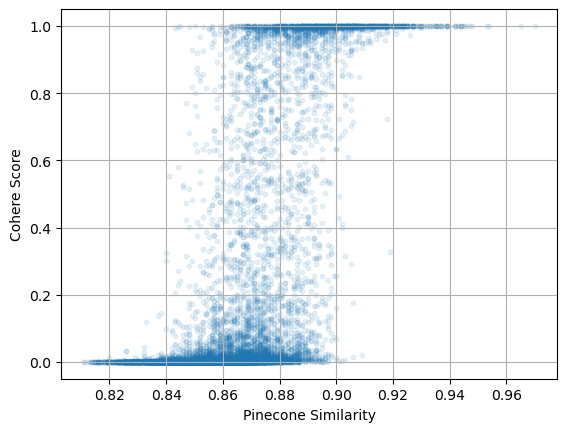

In [30]:
# scatter plot between cohere_score and similarity
plt.scatter(df_news['similarity'], df_news['cohere_score'], s=10, alpha=0.1)
plt.xlabel('Pinecone Similarity')
plt.ylabel('Cohere Score')
plt.grid(True)

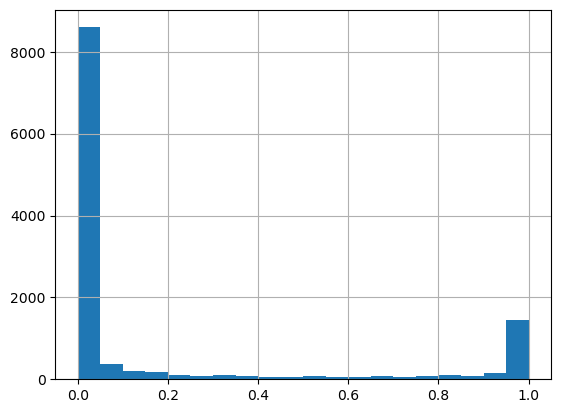

In [31]:
df_news['cohere_score'].hist(bins=20);

In [276]:
# cohere_score distribution by deciles
df_news.cohere_score = df_news.cohere_score.round(4)
df_news['cohere_score'].describe()

count    12000.000000
mean         0.325071
std          0.429043
min          0.000000
25%          0.000300
50%          0.011400
75%          0.895075
max          1.000000
Name: cohere_score, dtype: float64

In [277]:
# cohere_score distribution by deciles
df_news['cohere_score'].quantile([0.1, 0.2, 0.3, 0.4, 0.5,
                                  0.6, 0.7, 0.8, 0.9, 1.0])

0.1    0.00000
0.2    0.00010
0.3    0.00060
0.4    0.00230
0.5    0.01140
0.6    0.10544
0.7    0.65032
0.8    0.98330
0.9    0.99990
1.0    1.00000
Name: cohere_score, dtype: float64

Values are mostly at extremes. So either we set threshold at .8 or .7 does not differ much.

Set it at 0.8.

What %age of news (top30) would be relevant?

In [251]:
requests_total = df_news.groupby('request').news.count().sort_values(ascending=False)
requests_relevant = df_news.groupby('request')['is_relevant'].sum().sort_values(ascending=False)
# add 2 series to df_requests by request
df_requests['total'] = df_requests['text'].map(requests_total)
df_requests['relevant'] = df_requests['text'].map(requests_relevant)
df_requests['relevant_ratio'] = df_requests['relevant'] / df_requests['total']

In [282]:
df_requests.sort_values('relevant_ratio', ascending=False).head(10)

,id,date,text,total,relevant,relevant_ratio
24,944,2023-11-14,Армия обороны Израиля заявила о захвате нескол...,150,130,0.866667
25,943,2023-11-14,Министр обороны Израиля заявил о потере ХАМАС ...,150,124,0.826667
19,945,2023-11-15,Израильские военные зашли на территорию больни...,150,111,0.740000
35,941,2023-11-13,"Армия Израиля допросит 20 боевиков ХАМАС, заде...",150,105,0.700000
23,944,2023-11-14,Финляндия закроет границу с Россией на замок и...,150,102,0.680000
6,947,2023-11-16,Финляндия закроет четыре КПП на границе с Россией,300,196,0.653333
0,948,2023-11-17,Финляндия закроет четыре КПП на границе с Россией,300,196,0.653333
1,948,2023-11-17,В Астрахани в пятиэтажном доме обрушились два ...,150,96,0.640000
41,940,2023-11-12,МЧС сообщило о начале эвакуации россиян из сек...,150,94,0.626667
9,947,2023-11-16,В Астрахани рухнули два подъезда пятиэтажки,150,91,0.606667


For some topics too little relevant news. Let's check them. 

In [274]:
low_relev_requests =  df_requests.sort_values('relevant_ratio', ascending=False)['text'].iloc[-10:]
high_relev_requests =  df_requests.sort_values('relevant_ratio', ascending=False)['text'].iloc[:10]

In [281]:
df_news[df_news['request'].isin(high_relev_requests)].to_clipboard(index=False)

- Indeed some topics have very few news. 
- Seems that True story sometimes create cluster of just few news or picks just one small sub-topic as a name for cluster.

# Function for digest (pinecone + rerank)

So now ask_media algorithm:
- take 30 (50?) news from pinecone
- send them to ReRank and filter by cohere_score > 0.8
- calculate share of 0.8+ news among these 30
- summarize 0.8+ news in bullet points for each stance
- find common in all 5 stances in bullet points
- compare each stance with common points -> 1-3 key differences

In [65]:
# get relevant news from pinecone and make a dataframe
request = "Антон Красовский госпитализирован с подозрением на отравление"
stance = 'altern'
dates=['2023-12-24', '2023-12-27']

sim_news, news_links = utils.get_top_pine(request=request, dates=dates, stance=[stance], model="text-embedding-ada-002", top_n=top_n, join_news=False)

In [63]:
def cohere_rerank(request: str, sim_news: list, threshold = 0.8):
    # Cohere ReRank
    reranked_docs = co.rerank(model="rerank-multilingual-v2.0", query=request, documents=sim_news)

    # create a dataframe with news and cohere results
    df_reranked = pd.DataFrame({'news': sim_news})
    for i in range(len(reranked_docs.results)):
        index = reranked_docs.results[i].index
        df_reranked.loc[index, 'cohere_score'] = reranked_docs.results[i].relevance_score
        df_reranked.loc[index, 'is_relevant'] = 1 if reranked_docs.results[i].relevance_score > threshold else 0
    
    return df_reranked

In [66]:
df_reranked = cohere_rerank(request, sim_news)
df_reranked.shape

(30, 3)

In [70]:
len(df_reranked[df_reranked['is_relevant'] == 1])

4

In [69]:
df_reranked[df_reranked['is_relevant'] == 1]['news'].to_list()

['Журналист Антон Красовский сообщил о своей госпитализации, украинское издание со ссылкой на разведку утверждает, что его отравили     «В начале недели резко скрутило живот, начало тошнить, потом потерял сознание. Украинское издание Kyiv Post со ссылкой на источник в Главном управлении разведки Украины пишет, что Красовского отравили.',
 'По предварительной информации, задержан 19-летний посетитель, который, будучи не сильно трезвым, сначала демонстрировал посетителям пневматический пистолет, а на просьбу охраны убрать оружие дважды выстрелил в сторону двери. В Псковской области ввели штрафы за склонение женщин к абортам, пишет ТАСС со ссылкой на пресс-службу регионального парламента. После сообщений об отравлении главный редактор RT Маргарита Симоньян заявила, что Красовский приходит в себя и «все будет хорошо».',
 'Украинские СМИ утверждают, что его отравили  «В начале недели резко скрутило живот, начало тошнить, потом потерял сознание. Издание Kyiv Post со ссылкой на источник в Гла

In [59]:
len(df_temp[df_temp['is_relevant'] == 1])

0

### test utils.ask_media

In [4]:
request = "Антон Красовский госпитализирован с подозрением на отравление"
stance = ['altern']
dates=['2023-12-24', '2023-12-27']

In [7]:
str(dates)

"['2023-12-24', '2023-12-27']"

In [5]:
news4request, news_links = utils.get_top_pine(request, dates=dates, stance=stance, model="text-embedding-ada-002", top_n=30, join_news=False)

In [101]:
import importlib
importlib.reload(utils)

<module 'utils' from '/Users/alexbadin/Library/CloudStorage/GoogleDrive-alex.badin@gmail.com/My Drive/Colab Notebooks/Narratives/notebooks_news_digest/utils.py'>

In [16]:
news4request = utils.cohere_rerank(request, news4request, dates=dates, stance=stance, threshold = 0.8)

In [29]:
model_name = "gpt-3.5-turbo"
tokens_out = 512
utils.ask_openai(request, news4request, model_name = model_name, tokens_out = tokens_out)

<OpenAIObject chat.completion id=chatcmpl-8a18zOsFlgmV07u4G7lHS2kUPEVLR at 0x164e27fb0> JSON: {
  "id": "chatcmpl-8a18zOsFlgmV07u4G7lHS2kUPEVLR",
  "object": "chat.completion",
  "created": 1703594897,
  "model": "gpt-3.5-turbo-0613",
  "choices": [
    {
      "index": 0,
      "message": {
        "role": "assistant",
        "content": "\u0410\u043d\u0442\u043e\u043d \u041a\u0440\u0430\u0441\u043e\u0432\u0441\u043a\u0438\u0439 \u0433\u043e\u0441\u043f\u0438\u0442\u0430\u043b\u0438\u0437\u0438\u0440\u043e\u0432\u0430\u043d \u0441 \u043f\u043e\u0434\u043e\u0437\u0440\u0435\u043d\u0438\u0435\u043c \u043d\u0430 \u043e\u0442\u0440\u0430\u0432\u043b\u0435\u043d\u0438\u0435. \u0423\u043a\u0440\u0430\u0438\u043d\u0441\u043a\u043e\u0435 \u0438\u0437\u0434\u0430\u043d\u0438\u0435 Kyiv Post \u0441\u043e \u0441\u0441\u044b\u043b\u043a\u043e\u0439 \u043d\u0430 \u0438\u0441\u0442\u043e\u0447\u043d\u0438\u043a \u0432 \u0413\u043b\u0430\u0432\u043d\u043e\u043c \u0443\u043f\u0440\u0430\u0432\u043b\u

In [43]:
utils.ask_media(request, dates=dates, sources=None, stance=stance, model_name = "gpt-3.5-turbo", tokens_out = 512, full_reply = True, top_n = 10)

Request: Антон Красовский госпитализирован с подозрением на отравление; 
Filters: dates: ['2023-12-24', '2023-12-27']; sources: None; stance: ['altern']
0.0015674999999999999
1045
Антон Красовский госпитализирован с подозрением на отравление. Украинское издание Kyiv Post со ссылкой на разведку сообщает, что его отравили. Состояние здоровья Красовского ухудшается, и последняя запись в сети, вероятно, была сделана не им самим.
['https://t.me/redakciya_channel/28657 - 0.905', 'https://t.me/fontankaspb/49794 - 0.861', 'https://t.me/mediazzzona/13928 - 0.856', 'https://t.me/mediazzzona/13925 - 0.856', 'https://t.me/meduzalive/97332 - 0.852', 'https://t.me/redakciya_channel/28662 - 0.85', 'https://t.me/meduzalive/97331 - 0.849', 'https://t.me/fontankaspb/49798 - 0.848', 'https://t.me/radiosvoboda/53176 - 0.847', 'https://t.me/novaya_pishet/43075 - 0.843']


"Request: Антон Красовский госпитализирован с подозрением на отравление; \nFilters: dates: ['2023-12-24', '2023-12-27']; sources: None; stance: ['altern']\nCost per request: 0.002. Tokens used: 1045\n\nАнтон Красовский госпитализирован с подозрением на отравление. Украинское издание Kyiv Post со ссылкой на разведку сообщает, что его отравили. Состояние здоровья Красовского ухудшается, и последняя запись в сети, вероятно, была сделана не им самим.\n\n['https://t.me/redakciya_channel/28657 - 0.905', 'https://t.me/fontankaspb/49794 - 0.861', 'https://t.me/mediazzzona/13928 - 0.856', 'https://t.me/mediazzzona/13925 - 0.856', 'https://t.me/meduzalive/97332 - 0.852', 'https://t.me/redakciya_channel/28662 - 0.85', 'https://t.me/meduzalive/97331 - 0.849', 'https://t.me/fontankaspb/49798 - 0.848', 'https://t.me/radiosvoboda/53176 - 0.847', 'https://t.me/novaya_pishet/43075 - 0.843']"

In [48]:
from icecream import ic

def ask_media(request, dates=None, sources=None, stance=None, model_name = "gpt-3.5-turbo", tokens_out = 512, full_reply = True, top_n = 30):
    # check request time
    request_time = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime())

    # get top news
    # INPUT: request, dates, sources, stance
    # OUTPUT: news4request - list of news texts for openai, news_links - list of links
    news4request, news_links = utils.get_top_pine(request, dates=dates, sources=sources, stance=stance, model="text-embedding-ada-002", top_n=top_n, join_news=False)
    # filter news via Cohere ReRank (dates & stance for saving full results to csv)
    ic(request)
    ic(news4request)
    ic(dates)
    ic(stance)
    news4request = cohere_rerank(request, news4request, dates=dates, stance=stance, threshold = 0.8)

    # limit number of tokens vs model
    if model_name == "gpt-3.5-turbo":
        news4request = news4request[:4000]
    if model_name == "gpt-3.5-turbo-1106":
        news4request = news4request[:8000]
    elif model_name == "gpt-3.5-turbo-16k":
        news4request = news4request[:16000]
    elif model_name == "gpt-4":
        news4request = news4request[:8000]
    elif model_name == "gpt-4-32k":
        news4request = news4request[:32000]

    # get params for long reply
    request_params = f"Request: {request}; \nFilters: dates: {dates}; sources: {sources}; stance: {stance}"

    if len(news4request) == 0:
        reply_text = 'Нет новостей по теме'   
    else:
        reply = utils.ask_openai(request, news4request, model_name = model_name, tokens_out = tokens_out)
        reply_text = reply.choices[0]['message']['content']
        n_tokens_used = reply.usage.total_tokens
        price_1K = utils.get_price_per_1K(model_name)
        reply_cost = n_tokens_used / 1000 * price_1K

    # write params & reply to file. If file doesn't exist - create it with headers
    # check reply time
    reply_time = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime())
    
    if not os.path.isfile('openai_chatbot_digest_log.csv'):
        with open('openai_chatbot_digest_log.csv', 'a', newline='') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(['request', 'dates', 'sources', 'stance', 'reply_text', 'reply_cost', 'request_time', 'reply_time', 'model_name', 'n_tokens_used', 'news_links'])
    with open('openai_chatbot_digest_log.csv', 'a', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow([request, dates, sources, stance, reply_text, reply_cost, request_time, reply_time, model_name, n_tokens_used, news_links])
    
    # return reply for chatbot. If full_reply = False - return only reply_text
    if full_reply == False:
        return reply_text
    else:
        ic(request_params)
        ic(reply_cost)
        ic(n_tokens_used)
        ic(reply_text)
        ic(news_links)
        return request_params + "\n" + "Cost per request: " + str(round(reply_cost,3)) + ". Tokens used: " + str(n_tokens_used) + "\n\n" + reply_text + "\n\n" + str(news_links)

In [50]:
utils.ask_media(request, dates=dates, sources=None, stance=stance, model_name = "gpt-3.5-turbo", tokens_out = 512, full_reply = True, top_n = 10)

Request: Антон Красовский госпитализирован с подозрением на отравление; 
Filters: dates: ['2023-12-24', '2023-12-27']; sources: None; stance: ['altern']
0.0015975
1065
Антон Красовский госпитализирован с подозрением на отравление. Украинское издание Kyiv Post со ссылкой на источник в Главном управлении разведки Украины утверждает, что его отравили. Состояние здоровья Красовского ухудшается, и последняя запись в сети, возможно, была сделана не им самим.
['https://t.me/redakciya_channel/28657 - 0.907', 'https://t.me/fontankaspb/49794 - 0.863', 'https://t.me/mediazzzona/13928 - 0.858', 'https://t.me/mediazzzona/13925 - 0.857', 'https://t.me/meduzalive/97332 - 0.854', 'https://t.me/redakciya_channel/28662 - 0.853', 'https://t.me/fontankaspb/49798 - 0.85', 'https://t.me/meduzalive/97331 - 0.85', 'https://t.me/radiosvoboda/53176 - 0.847', 'https://t.me/radiosvoboda/53167 - 0.845']


"Request: Антон Красовский госпитализирован с подозрением на отравление; \nFilters: dates: ['2023-12-24', '2023-12-27']; sources: None; stance: ['altern']\nCost per request: 0.002. Tokens used: 1065\n\nАнтон Красовский госпитализирован с подозрением на отравление. Украинское издание Kyiv Post со ссылкой на источник в Главном управлении разведки Украины утверждает, что его отравили. Состояние здоровья Красовского ухудшается, и последняя запись в сети, возможно, была сделана не им самим.\n\n['https://t.me/redakciya_channel/28657 - 0.907', 'https://t.me/fontankaspb/49794 - 0.863', 'https://t.me/mediazzzona/13928 - 0.858', 'https://t.me/mediazzzona/13925 - 0.857', 'https://t.me/meduzalive/97332 - 0.854', 'https://t.me/redakciya_channel/28662 - 0.853', 'https://t.me/fontankaspb/49798 - 0.85', 'https://t.me/meduzalive/97331 - 0.85', 'https://t.me/radiosvoboda/53176 - 0.847', 'https://t.me/radiosvoboda/53167 - 0.845']"

In [57]:
utils.clean_text_topic('❶ Журналистку из (https://t.me/truestorymedia/12568) Читы Нику Новак арестовали по статье о сотрудничестве с иностранной организацией (19)')

'Журналистку из Читы Нику Новак арестовали по статье о сотрудничестве с иностранной организацией'

In [89]:
request = 'На Ивлееву подали иск на 1 млрд рублей из-за «голой вечеринки» звезд'
request = utils.clean_text_topic(request)
request_emb = utils.get_embedding(request)

In [105]:
top_n = 30
stance = 'moder'
start_date = int(datetime.strptime('2023-12-26', '%Y-%m-%d').timestamp())
end_date = int(datetime.strptime('2023-12-28', '%Y-%m-%d').timestamp())

filter = {
        "stance": { "$eq": stance },
        "date": { "$gte": start_date, "$lte": end_date }
        }

res = index.query(request_emb, top_k=top_n, include_metadata=True, filter=filter)
len(res.to_dict()['matches'])

30